# 01. Setup dan Eksplorasi Dataset

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
CM_DIR = RESULTS_DIR / "confusion_matrix"
MODELS_DIR = PROJECT_ROOT / "models"
LAPORAN_DIR = PROJECT_ROOT / "laporan"

for path in [DATA_DIR, RESULTS_DIR, CM_DIR, MODELS_DIR, LAPORAN_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir    :", DATA_DIR)
print("Results dir :", RESULTS_DIR)
print("Models dir  :", MODELS_DIR)

Project root: C:\UTS_Data_Mining
Data dir    : C:\UTS_Data_Mining\data
Results dir : C:\UTS_Data_Mining\results
Models dir  : C:\UTS_Data_Mining\models


In [3]:
CONFIG = {
    "random_seed": 42,
    "batch_size": 64,
    "num_classes": 10,
    "input_size": 784,
    "svm_train_subset": 10000,
    "svm_test_subset": 2000
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Membuat hasil lebih reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["random_seed"])
print("Random seed:", CONFIG["random_seed"])

Random seed: 42


In [4]:
print("Python version     :", sys.version.split()[0])
print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available     :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device digunakan   :", device)

if torch.cuda.is_available():
    print("GPU terdeteksi     :", torch.cuda.get_device_name(0))
else:
    print("CUDA tidak tersedia. Notebook tetap dapat berjalan menggunakan CPU.")

Python version     : 3.11.5
PyTorch version    : 2.12.0+cu126
Torchvision version: 0.27.0+cu126
CUDA available     : True
Device digunakan   : cuda
GPU terdeteksi     : NVIDIA GeForce RTX 3050 Laptop GPU


In [5]:
transform = transforms.ToTensor()

try:
    mnist_train = datasets.MNIST(
        root=DATA_DIR,
        train=True,
        download=True,
        transform=transform
    )

    mnist_test = datasets.MNIST(
        root=DATA_DIR,
        train=False,
        download=True,
        transform=transform
    )

    fashion_train = datasets.FashionMNIST(
        root=DATA_DIR,
        train=True,
        download=True,
        transform=transform
    )

    fashion_test = datasets.FashionMNIST(
        root=DATA_DIR,
        train=False,
        download=True,
        transform=transform
    )

    print("Dataset berhasil dimuat.")

except Exception as e:
    print("Gagal memuat dataset.")
    print("Pastikan koneksi internet aktif saat pertama kali download dataset.")
    raise e

100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%

Dataset berhasil dimuat.


In [6]:
dataset_summary = pd.DataFrame([
    {"Dataset": "MNIST", "Train": len(mnist_train), "Test": len(mnist_test), "Image Size": "28 x 28", "Classes": 10},
    {"Dataset": "Fashion MNIST", "Train": len(fashion_train), "Test": len(fashion_test), "Image Size": "28 x 28", "Classes": 10},
])

display(dataset_summary)

,Dataset,Train,Test,Image Size,Classes
0,MNIST,60000,10000,28 x 28,10
1,Fashion MNIST,60000,10000,28 x 28,10


In [7]:
mnist_classes = [str(i) for i in range(10)]

fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Kelas MNIST:")
print(mnist_classes)

print("\nKelas Fashion MNIST:")
print(fashion_classes)

Kelas MNIST:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Kelas Fashion MNIST:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


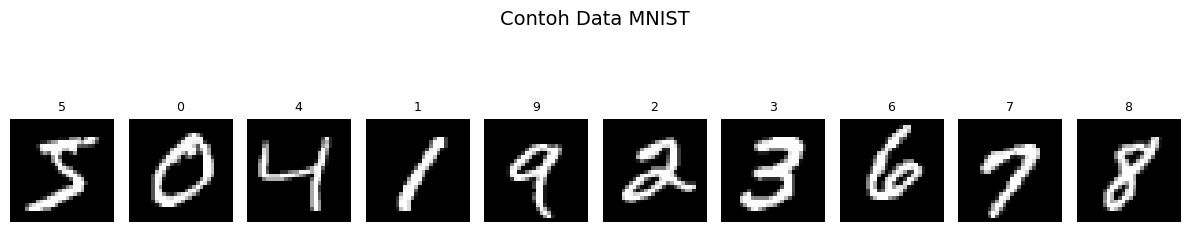

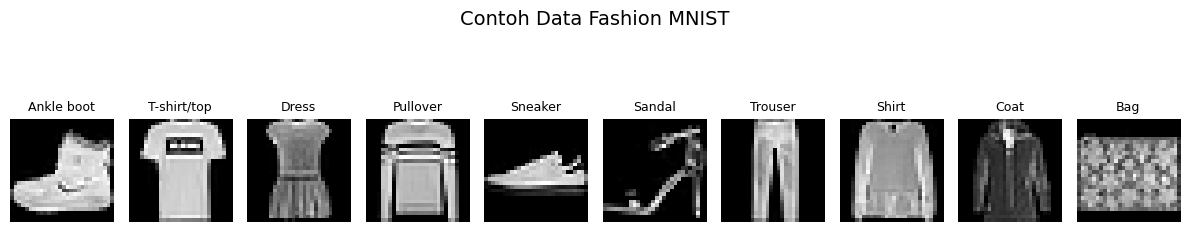

In [8]:
def show_sample_images(dataset, class_names, title, n=10):
    plt.figure(figsize=(12, 3))

    shown_labels = set()
    selected_indices = []

    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if label not in shown_labels:
            shown_labels.add(label)
            selected_indices.append(idx)
        if len(selected_indices) == n:
            break

    for i, idx in enumerate(selected_indices):
        image, label = dataset[idx]
        plt.subplot(1, n, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(class_names[label], fontsize=9)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(mnist_train, mnist_classes, "Contoh Data MNIST")
show_sample_images(fashion_train, fashion_classes, "Contoh Data Fashion MNIST")

In [9]:
sample_image, sample_label = mnist_train[0]

print("Shape citra asli:", sample_image.shape)
print("Label:", sample_label)

flattened = sample_image.view(-1)
print("Shape setelah flatten:", flattened.shape)
print("Jumlah fitur:", flattened.numel())

Shape citra asli: torch.Size([1, 28, 28])
Label: 5
Shape setelah flatten: torch.Size([784])
Jumlah fitur: 784
